<a href="https://colab.research.google.com/github/FarhanN0250/PDM/blob/main/pdm_project_MLFlow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Library & Konfigurasi MLflow


In [1]:
!pip install -q mlflow streamlit pyngrok xgboost lightgbm "kagglehub[pandas-datasets]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 974.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/13

In [2]:
import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.feature_selection import mutual_info_regression

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import mlflow
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.pyfunc
from mlflow.models import infer_signature

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# ===== CONFIG MLflow =====
# Pilihan 1: gunakan server seperti contoh
TRACKING_URI = "http://202.91.9.5:5000"

# Pilihan 2: gunakan local tracking jika server tidak aktif
# TRACKING_URI = "./mlruns"

EXPERIMENT_NAME = "PDM_EAFC26_Player_Value_Prediction"
REGISTERED_MODEL_NAME = "EAFC26_Market_Value_Model"
ARTIFACT_DIR = "artifacts_pdm_mlflow"

os.makedirs(ARTIFACT_DIR, exist_ok=True)

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow Tracking URI:", mlflow.get_tracking_uri())
print("Experiment:", EXPERIMENT_NAME)


2026/05/23 06:49:33 INFO mlflow.tracking.fluent: Experiment with name 'PDM_EAFC26_Player_Value_Prediction' does not exist. Creating a new experiment.


MLflow Tracking URI: http://202.91.9.5:5000
Experiment: PDM_EAFC26_Player_Value_Prediction


install library yang dibutuhkan seperti mlflow untuk tracking eksperimen, streamlit untuk deployment aplikasi, pyngrok untuk membuat link publik, serta xgboost dan lightgbm untuk model machine learning.

Setelah itu,import library untuk pengolahan data, visualisasi, pembagian data train-test, evaluasi model, pemilihan fitur, serta model XGBoost dan LightGBM. Kode juga meng-import MLflow agar proses training, metric, artifact, dan model dapat dicatat secara otomatis.


Pada bagian konfigurasi MLflow, TRACKING_URI menentukan lokasi penyimpanan hasil eksperimen, EXPERIMENT_NAME adalah nama eksperimen, REGISTERED_MODEL_NAME adalah nama model yang akan diregistrasi, dan ARTIFACT_DIR adalah folder untuk menyimpan file hasil training. Terakhir, mlflow.set_tracking_uri() dan mlflow.set_experiment() digunakan untuk menghubungkan notebook ke MLflow dan menentukan eksperimen yang aktif.

## 2. Load Data


In [3]:
import kagglehub
import pandas as pd
import os
from kagglehub import KaggleDatasetAdapter

# ==========================================================
# LOAD DATA LANGSUNG DARI KAGGLE
# ==========================================================
print("Mengunduh dataset dari Kaggle... (Tunggu sebentar)")

try:
    # Mengunduh folder dataset ke penyimpanan sementara Colab
    dataset_path = kagglehub.dataset_download("rovnez/fc-26-fifa-26-player-data")

    # Mencari otomatis nama file CSV di dalam folder yang diunduh
    csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

    if not csv_files:
        raise FileNotFoundError("Tidak ada file CSV yang ditemukan di dalam dataset Kaggle.")

    # Mengambil file CSV pertama yang ditemukan (misal: FC26_20250921.csv)
    file_path = csv_files[0]
    print(f"File ditemukan: {file_path}")

    # Memuat data menggunakan KaggleDatasetAdapter (sesuai request)
    df = kagglehub.load_dataset(
      KaggleDatasetAdapter.PANDAS,
      "rovnez/fc-26-fifa-26-player-data",
      file_path
    )

    print("\n===============================================")
    print("✅ DATASET BERHASIL DIMUAT DARI KAGGLE")
    print("===============================================")
    print(f"Total Baris: {df.shape[0]}")
    print(f"Total Kolom: {df.shape[1]}")
    display(df.head())

except Exception as e:
    print(f"❌ Terjadi kesalahan saat memuat data: {e}")

Mengunduh dataset dari Kaggle... (Tunggu sebentar)


100%|██████████| 3.04M/3.04M [00:00<00:00, 44.2MB/s]

Extracting files...


File ditemukan: FC26_20250921.csv
Using Colab cache for faster access to the 'fc-26-fifa-26-player-data' dataset.

✅ DATASET BERHASIL DIMUAT DARI KAGGLE
Total Baris: 18405
Total Kolom: 110


,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
0,252371,/player/252371/jude-bellingham/260004/,26,4,2025-09-19,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",90,94,...,85+3,85+3,83+3,82+3,81+3,81+3,81+3,82+3,18+3,https://cdn.sofifa.net/players/252/371/26_120.png
1,239053,/player/239053/federico-valverde/260004/,26,4,2025-09-19,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",89,90,...,87+3,87+3,86+3,86+3,83+3,83+3,83+3,86+3,18+3,https://cdn.sofifa.net/players/239/053/26_120.png
2,212622,/player/212622/joshua-kimmich/260004/,26,4,2025-09-19,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",89,89,...,87+2,87+2,86+3,85+3,82+3,82+3,82+3,85+3,21+3,https://cdn.sofifa.net/players/212/622/26_120.png
3,235212,/player/235212/achraf-hakimi/260004/,26,4,2025-09-19,A. Hakimi,Achraf Hakimi Mouhأشرف حكيمي,"RB, RM",89,90,...,83+3,83+3,86+3,86+3,81+3,81+3,81+3,86+3,17+3,https://cdn.sofifa.net/players/235/212/26_120.png
4,224232,/player/224232/nicolo-barella/260004/,26,4,2025-09-19,N. Barella,Nicolò Barella,CM,87,87,...,85+2,85+2,84+3,83+3,80+3,80+3,80+3,83+3,19+3,https://cdn.sofifa.net/players/224/232/26_120.png


memuat dataset dari Google Drive

## 3. Data Preprocessing, Filtering & Pemilihan Fitur Krusial

Tahap ini mengikuti project awal, tetapi fitur untuk model **dibatasi ke fitur yang paling relevan dan mudah diisi user** agar form Streamlit tidak terlalu panjang.

Fitur yang dipakai:
- `release_clause_eur`
- `overall`
- `potential`
- `wage_eur`
- `age`
- `international_reputation`


Catatan penting: semua fitur dikonversi ke `float64` supaya schema MLflow konsisten dengan input Streamlit.


In [4]:
# ==========================================================
# 1. PERSIAPAN DATA
# ==========================================================
df_model = df.copy()

df_model = df_model.dropna(subset=['value_eur'])
df_model = df_model[df_model['value_eur'] > 0]

print(f"Jumlah pemain siap diproses: {df_model.shape[0]} baris")

# ==========================================================
# 2. FEATURE ENGINEERING (Disederhanakan untuk mencegah redundansi)
# ==========================================================
# Hanya mempertahankan deteksi wonderkid. Fitur age_squared dan wage_efficiency dibuang.
df_model['potential_growth'] = df_model['potential'] - df_model['overall']

target = 'value_eur'
y = df_model[target].astype('float64')

# ==========================================================
# 3. MENCEGAH DATA LEAKAGE & BIAS POSISI
# ==========================================================
numeric_df = df_model.select_dtypes(include=['int64', 'float64'])
X_all = numeric_df.drop(columns=[target])

# Daftar pembersihan ketat: Leakage, Metadata, dan Sub-Atribut (Skill In-game)
kolom_dibuang = [
    'release_clause_eur',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'sofifa_id', 'player_id', 'club_team_id', 'league_id', 'nationality_id',
    'club_jersey_number', 'nation_jersey_number', 'club_contract_valid_until_year',
    'height_cm', 'weight_kg', 'weak_foot', 'skill_moves'
]

prefix_sub_atribut = [
    'attacking_', 'skill_', 'movement_', 'power_',
    'mentality_', 'defending_', 'goalkeeping_'
]

# Kumpulkan semua nama kolom
kolom_detail_dibuang = [col for col in X_all.columns if any(col.startswith(prefix) for prefix in prefix_sub_atribut)]
total_kolom_dibuang = kolom_dibuang + kolom_detail_dibuang

# Hapus dari dataset
X_all = X_all.drop(columns=[col for col in total_kolom_dibuang if col in X_all.columns])

# ==========================================================
# 4. AUTOMATIC FEATURE SELECTION
# ==========================================================
print("\nMelakukan seleksi fitur otomatis (Mutual Information)...")
X_all = X_all.fillna(X_all.median(numeric_only=True)).fillna(0)

# Hitung Information Gain
mi_scores = mutual_info_regression(X_all, y, random_state=42)
mi_scores_df = pd.Series(mi_scores, name='MI_Score', index=X_all.columns).sort_values(ascending=False)

# THRESHOLD DINAMIS
THRESHOLD = 0.1
fitur_terpilih = mi_scores_df[mi_scores_df >= THRESHOLD].index.tolist()

X = X_all[fitur_terpilih].copy().astype('float64')

print("\n===============================================")
print(f"AUTOMATIC FEATURE REDUCTION BERHASIL")
print("===============================================")
print(f"Terpilih {len(fitur_terpilih)} fitur paling murni & krusial:")
display(mi_scores_df[mi_scores_df >= THRESHOLD].to_frame())

# ==========================================================
# 5. ARTIFACT UNTUK MLFLOW DAN DEPLOYMENT STREAMLIT
# ==========================================================
ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

with open(os.path.join(ARTIFACT_DIR, 'feature_names.json'), 'w') as f:
    json.dump(fitur_terpilih, f, indent=4)

mi_scores_df.to_csv(os.path.join(ARTIFACT_DIR, 'mutual_information_scores.csv'), header=True)

feature_config = {}
for col in fitur_terpilih:
    feature_config[col] = {
        'min': float(X[col].min()),
        'max': float(X[col].max()),
        'median': float(X[col].median())
    }

with open(os.path.join(ARTIFACT_DIR, 'feature_config.json'), 'w') as f:
    json.dump(feature_config, f, indent=4)

Jumlah pemain siap diproses: 18296 baris

Melakukan seleksi fitur otomatis (Mutual Information)...

AUTOMATIC FEATURE REDUCTION BERHASIL
Terpilih 6 fitur paling murni & krusial:


,MI_Score
overall,1.32
potential,1.00
wage_eur,0.60
age,0.24
potential_growth,0.23
international_reputation,0.12


## 4. Exploratory Data Analysis (EDA)

Bagian visualisasi ini tetap dipertahankan dari project awal.


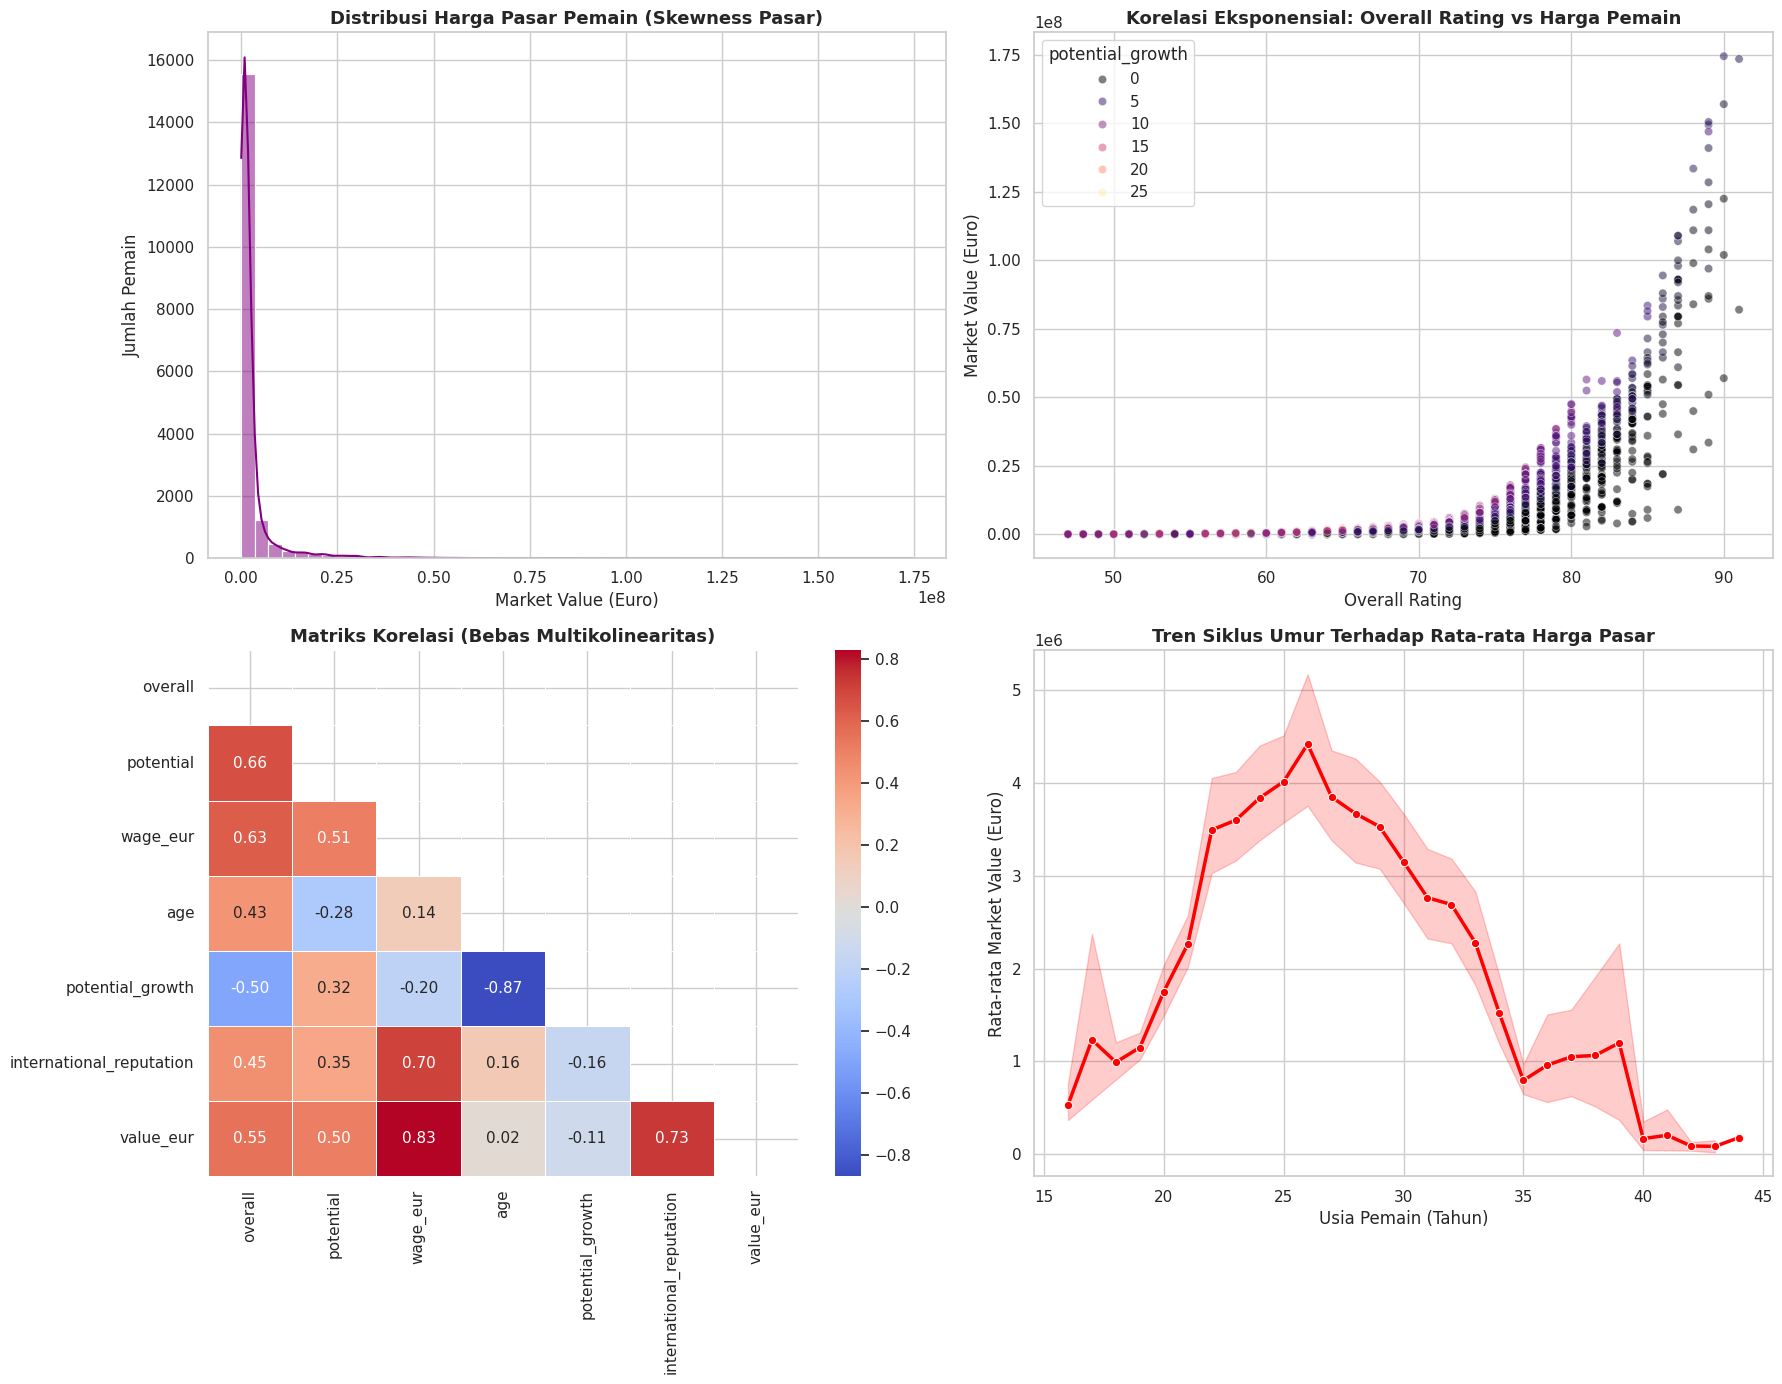

In [5]:
# ==========================================================
# EXPLORATORY DATA ANALYSIS (EDA) TINGKAT LANJUT
# ==========================================================
# Membuat DataFrame khusus EDA yang menggabungkan Fitur Krusial & Target
df_eda = X.copy()
df_eda['value_eur'] = y

# Mengatur tema visual agar terlihat profesional dan bersih
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ----------------------------------------------------------
# 1. DISTRIBUSI TARGET & DETEKSI OUTLIERS (Top-Left)
# ----------------------------------------------------------
# Menampilkan ketimpangan pasar (skewness). Mayoritas pemain murah, sedikit yang sangat mahal (superstar).
sns.histplot(df_eda['value_eur'], bins=50, kde=True, color='purple', ax=axes[0, 0])
axes[0, 0].set_title('Distribusi Harga Pasar Pemain (Skewness Pasar)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Market Value (Euro)')
axes[0, 0].set_ylabel('Jumlah Pemain')

# ----------------------------------------------------------
# 2. ANALISIS TREN NON-LINEAR: RATINGS VS HARGA (Top-Right)
# ----------------------------------------------------------
# Membuktikan bahwa harga pemain naik secara eksponensial seiring tingginya Overall Rating
sns.scatterplot(
    x='overall',
    y='value_eur',
    hue='potential_growth',
    palette='magma',
    alpha=0.5,
    data=df_eda,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Korelasi Eksponensial: Overall Rating vs Harga Pemain', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Overall Rating')
axes[0, 1].set_ylabel('Market Value (Euro)')

# ----------------------------------------------------------
# 3. MATRIKS KORELASI FITUR KRUSIAL (Bottom-Left)
# ----------------------------------------------------------
# Membuktikan kepada reviewer bahwa kita sudah membersihkan multikolinearitas
korelasi = df_eda.corr()
mask = np.triu(np.ones_like(korelasi, dtype=bool)) # Membuat segitiga atas transparan agar rapi
sns.heatmap(
    korelasi,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={"size": 11},
    ax=axes[1, 0]
)
axes[1, 0].set_title('Matriks Korelasi (Bebas Multikolinearitas)', fontsize=13, fontweight='bold')

# ----------------------------------------------------------
# 4. SIKLUS USIA TERHADAP VALUASI PASAR (Bottom-Right)
# ----------------------------------------------------------
# Menunjukkan tren kurva usia pemain: naik di usia muda, puncak di usia emas, turun di usia tua.
if 'age' in df_eda.columns:
    sns.lineplot(
        x='age',
        y='value_eur',
        data=df_eda,
        color='red',
        marker='o',
        linewidth=2.5,
        ax=axes[1, 1]
    )
    axes[1, 1].set_title('Tren Siklus Umur Terhadap Rata-rata Harga Pasar', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Usia Pemain (Tahun)')
    axes[1, 1].set_ylabel('Rata-rata Market Value (Euro)')
else:
    # Jika variabel age tidak ada, tampilkan visualisasi reputasi internasional
    sns.barplot(x='international_reputation', y='value_eur', data=df_eda, palette='Blues', ax=axes[1, 1])
    axes[1, 1].set_title('Pengaruh Reputasi Internasional Terhadap Valuasi', fontsize=13, fontweight='bold')

# Merapikan tata letak antar grafik
plt.tight_layout()
plt.show()

## 5. Modelling + Tracking & Logging MLflow

Pada tahap ini setiap model akan dicatat ke MLflow:

- **parameter model**
- **informasi dataset**
- **daftar fitur krusial**
- **metrics evaluasi**: R², MAE, RMSE
- **artifact**: daftar fitur, konfigurasi input, skor Mutual Information, sample prediksi, feature importance
- **model**: XGBoost dan LightGBM dalam format MLflow model

Karena `X` sudah dikonversi ke `float64`, schema MLflow akan cocok dengan input dari Streamlit.


In [10]:
# Split Data 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Data Latih: {X_train.shape[0]} baris")
print(f"Data Uji: {X_test.shape[0]} baris")
print(f"Jumlah fitur: {X_train.shape[1]}")

# Define missing paths used for logging artifacts
feature_path = os.path.join(ARTIFACT_DIR, 'feature_names.json')
mi_path = os.path.join(ARTIFACT_DIR, 'mutual_information_scores.csv')
feature_config_path = os.path.join(ARTIFACT_DIR, 'feature_config.json')

models = {
    "XGBoost": {
        "model": XGBRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        ),
        "params": {
            "n_estimators": 200,
            "learning_rate": 0.1,
            "max_depth": 6,
            "random_state": 42
        },
        "flavor": "xgboost"
    },
    "LightGBM": {
        "model": LGBMRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            random_state=42
        ),
        "params": {
            "n_estimators": 200,
            "learning_rate": 0.1,
            "max_depth": 6,
            "random_state": 42
        },
        "flavor": "lightgbm"
    }
}

results = []

for model_name, cfg in models.items():
    model = cfg["model"]
    params = cfg["params"]
    flavor = cfg["flavor"]

    print(f"\n{'='*60}")
    print(f"Training dan logging model: {model_name}")
    print(f"{'='*60}")

    with mlflow.start_run(run_name=model_name) as run:
        run_id = run.info.run_id

        # ===== Logging parameter model =====
        mlflow.log_params(params)
        mlflow.log_param("target", target)
        mlflow.log_param("feature_selection_method", "Manual Crucial Features + Mutual Information Documentation")
        mlflow.log_param("num_selected_features", len(fitur_terpilih))
        mlflow.log_param("train_rows", X_train.shape[0])
        mlflow.log_param("test_rows", X_test.shape[0])

        # ===== Train model =====
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # ===== Metrics =====
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        mlflow.log_metrics({
            "r2_score": r2,
            "mae": mae,
            "rmse": rmse
        })

        # ===== Artifact: sample prediction =====
        pred_df = pd.DataFrame({
            "actual_value_eur": y_test.values,
            "predicted_value_eur": y_pred,
            "absolute_error": np.abs(y_test.values - y_pred)
        })
        pred_path = os.path.join(ARTIFACT_DIR, f"predictions_{model_name}.csv")
        pred_df.to_csv(pred_path, index=False)
        mlflow.log_artifact(pred_path, artifact_path="evaluation")

        # ===== Artifact: feature names & MI scores =====
        mlflow.log_artifact(feature_path, artifact_path="features")
        mlflow.log_artifact(mi_path, artifact_path="features")
        mlflow.log_artifact(feature_config_path, artifact_path="features")

        # ===== Artifact: feature importance =====
        if hasattr(model, "feature_importances_"):
            fi = pd.Series(model.feature_importances_, index=fitur_terpilih).sort_values(ascending=False)
            fi_path = os.path.join(ARTIFACT_DIR, f"feature_importance_{model_name}.csv")
            fi.to_csv(fi_path, header=["importance"])
            mlflow.log_artifact(fi_path, artifact_path="features")

            plt.figure(figsize=(10, 8))
            sns.barplot(x=fi.head(15), y=fi.head(15).index)
            plt.title(f"Top 15 Feature Importance - {model_name}")
            plt.xlabel("Importance")
            plt.ylabel("Feature")
            plt.tight_layout()
            fig_path = os.path.join(ARTIFACT_DIR, f"feature_importance_{model_name}.png")
            plt.savefig(fig_path, dpi=150)
            plt.close()
            mlflow.log_artifact(fig_path, artifact_path="plots")

        # ===== Artifact: joblib model backup =====
        pkl_path = os.path.join(ARTIFACT_DIR, f"model_{model_name}.pkl")
        joblib.dump(model, pkl_path)
        mlflow.log_artifact(pkl_path, artifact_path="model_backup")

        # ===== Log MLflow model =====
        input_example = X_train.head(3).astype("float64")
        signature = infer_signature(X_train.astype("float64"), model.predict(X_train.astype("float64")))

        if flavor == "xgboost":
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path="model",
                input_example=input_example,
                signature=signature
            )
        elif flavor == "lightgbm":
            mlflow.lightgbm.log_model(
                lgb_model=model,
                artifact_path="model",
                input_example=input_example,
                signature=signature
            )

        results.append({
            "model_name": model_name,
            "run_id": run_id,
            "r2_score": r2,
            "mae": mae,
            "rmse": rmse,
            "model_uri": f"runs:/{run_id}/model"
        })

        print(f"Run ID   : {run_id}")
        print(f"R2 Score : {r2:.4f}")
        print(f"MAE      : • {mae:,.0f}")
        print(f"RMSE     : • {rmse:,.0f}")

results_df = pd.DataFrame(results).sort_values("rmse", ascending=True)
print("\nHASIL PERBANDINGAN MODEL")
display(results_df)

Data Latih: 14636 baris
Data Uji: 3660 baris
Jumlah fitur: 6

Training dan logging model: XGBoost


2026/05/23 07:13:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Run ID   : 1ad74edf98044f2fbc0660b557257943
R2 Score : 0.9901
MAE      : • 199,063
RMSE     : • 786,958
🏃 View run XGBoost at: http://202.91.9.5:5000/#/experiments/44/runs/1ad74edf98044f2fbc0660b557257943
🧪 View experiment at: http://202.91.9.5:5000/#/experiments/44

Training dan logging model: LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001052 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 277
[LightGBM] [Info] Number of data points in the train set: 14636, number of used features: 6
[LightGBM] [Info] Start training from score 2958584.788535
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

2026/05/23 07:13:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/23 07:13:55 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run ID   : 87af48852b1b4ea689541c15c6974a86
R2 Score : 0.9820
MAE      : • 234,931
RMSE     : • 1,062,233
🏃 View run LightGBM at: http://202.91.9.5:5000/#/experiments/44/runs/87af48852b1b4ea689541c15c6974a86
🧪 View experiment at: http://202.91.9.5:5000/#/experiments/44

HASIL PERBANDINGAN MODEL


,model_name,run_id,r2_score,mae,rmse,model_uri
0,XGBoost,1ad74edf98044f2fbc0660b557257943,0.99,199062.99,786958.03,runs:/1ad74edf98044f2fbc0660b557257943/model
1,LightGBM,87af48852b1b4ea689541c15c6974a86,0.98,234931.18,1062232.86,runs:/87af48852b1b4ea689541c15c6974a86/model


## 6. Pilih Best Model dan Register ke MLflow Model Registry

Model terbaik dipilih berdasarkan nilai **RMSE paling kecil**.


In [11]:
best_model_info = results_df.iloc[0].to_dict()
best_model_name = best_model_info["model_name"]
best_run_id = best_model_info["run_id"]
best_model_uri = best_model_info["model_uri"]

print("Best Model:", best_model_name)
print("Best Run ID:", best_run_id)
print("Best Model URI:", best_model_uri)

# Register best model ke MLflow Model Registry
# Jika registry server tidak tersedia, bagian ini akan dilewati dan tetap bisa memakai runs:/.../model
try:
    registered_model = mlflow.register_model(
        model_uri=best_model_uri,
        name=REGISTERED_MODEL_NAME
    )
    print("Model berhasil diregister!")
    print("Registered Model Name:", registered_model.name)
    print("Version:", registered_model.version)
    DEPLOY_MODEL_URI = f"models:/{REGISTERED_MODEL_NAME}/{registered_model.version}"
except Exception as e:
    print("Register model gagal atau registry tidak tersedia.")
    print("Error:", e)
    print("Deployment akan memakai model URI dari run terbaik.")
    DEPLOY_MODEL_URI = best_model_uri

print("DEPLOY_MODEL_URI:", DEPLOY_MODEL_URI)


Best Model: XGBoost
Best Run ID: 1ad74edf98044f2fbc0660b557257943
Best Model URI: runs:/1ad74edf98044f2fbc0660b557257943/model


Successfully registered model 'EAFC26_Market_Value_Model'.
2026/05/23 07:14:11 WARNING mlflow.tracking._model_registry.fluent: Run with id 1ad74edf98044f2fbc0660b557257943 has no artifacts at artifact path 'model', registering model based on models:/m-c57a7bdf83254a26b3b596ac292f683f instead
2026/05/23 07:14:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: EAFC26_Market_Value_Model, version 1
Created version '1' of model 'EAFC26_Market_Value_Model'.


Model berhasil diregister!
Registered Model Name: EAFC26_Market_Value_Model
Version: 1
DEPLOY_MODEL_URI: models:/EAFC26_Market_Value_Model/1


## 7. Load Model dari MLflow dan Test Prediction

Cell ini memastikan model yang sudah di-log ke MLflow bisa dipanggil kembali.


In [12]:
loaded_model = mlflow.pyfunc.load_model(DEPLOY_MODEL_URI)

sample_input = X_test.head(5)
sample_prediction = loaded_model.predict(sample_input)

sample_result = sample_input.copy()
sample_result["predicted_value_eur"] = sample_prediction
sample_result["actual_value_eur"] = y_test.head(5).values

display(sample_result)


,overall,potential,wage_eur,age,potential_growth,international_reputation,predicted_value_eur,actual_value_eur
3615,63.00,63.00,1000.00,27.00,0.00,1.00,490476.41,500000.00
16693,75.00,75.00,9000.00,36.00,0.00,1.00,1305061.12,625000.00
16634,75.00,76.00,6000.00,29.00,1.00,1.00,4333812.00,4300000.00
5299,66.00,80.00,8000.00,19.00,14.00,1.00,2011349.38,2000000.00
16439,47.00,60.00,2000.00,21.00,13.00,1.00,117910.73,110000.00


## 8. Deployment Streamlit

Cell ini membuat file `app.py`. Aplikasi Streamlit akan:

- load model dari MLflow menggunakan `DEPLOY_MODEL_URI`
- menyediakan form input hanya untuk fitur krusial
- memakai default nilai median dari data training
- mengirim input sebagai `float64` agar tidak terjadi error schema MLflow
- menampilkan hasil prediksi market value pemain


In [13]:
# Buat app.py untuk deployment Streamlit
# Catatan: input_df dikonversi ke float64 untuk mencegah error schema MLflow.

feature_config_json = json.dumps(feature_config, indent=4)
feature_names_json = json.dumps(fitur_terpilih, indent=4)

app_code = f"""
import os
import mlflow
import mlflow.pyfunc
import pandas as pd
import streamlit as st

# ===== CONFIG =====
TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "{TRACKING_URI}")
MODEL_URI = os.getenv("MLFLOW_MODEL_URI", "{DEPLOY_MODEL_URI}")
FEATURE_NAMES = {feature_names_json}
FEATURE_CONFIG = {feature_config_json}

mlflow.set_tracking_uri(TRACKING_URI)

# ===== LOAD MODEL =====
@st.cache_resource
def load_model(model_uri):
    return mlflow.pyfunc.load_model(model_uri)

# ===== UI =====
st.set_page_config(page_title="EAFC 26 Player Value Prediction", layout="wide")

st.title("⚽ EAFC 26 Player Market Value Prediction")
st.write("Deployment model regresi menggunakan MLflow + Streamlit dengan fitur krusial.")

with st.sidebar:
    st.header("MLflow Config")
    st.write("Tracking URI:")
    st.code(TRACKING_URI)
    st.write("Model URI:")
    st.code(MODEL_URI)
    st.caption("Jika ingin memakai model lain, ubah environment variable MLFLOW_TRACKING_URI dan MLFLOW_MODEL_URI.")

try:
    model = load_model(MODEL_URI)
    st.success("✅ Model berhasil dimuat dari MLflow")
except Exception as e:
    st.error(f"❌ Model gagal dimuat: {{e}}")
    st.stop()

st.subheader("📥 Input Data Pemain")
st.write("Isi nilai fitur utama pemain. Jumlah fitur sudah dikurangi agar lebih mudah digunakan.")

features = {{}}
cols = st.columns(2)

for idx, feature in enumerate(FEATURE_NAMES):
    cfg = FEATURE_CONFIG.get(feature, {{}})
    default_value = float(cfg.get("median", 0.0))
    min_value = float(cfg.get("min", 0.0))
    max_value = float(cfg.get("max", max(default_value * 2, 1.0)))

    # Agar tidak error jika min dan max sama
    if max_value <= min_value:
        max_value = min_value + 1.0

    with cols[idx % 2]:
        features[feature] = st.number_input(
            label=feature,
            min_value=min_value,
            max_value=max_value,
            value=default_value,
            step=1.0,
            format="%.2f"
        )

# Wajib float64 agar cocok dengan MLflow model signature
input_df = pd.DataFrame([features], columns=FEATURE_NAMES).astype("float64")

st.subheader("🔍 Prediction")
if st.button("Predict Market Value"):
    try:
        prediction = model.predict(input_df)
        pred_value = float(prediction[0])
        st.success(f"💰 Prediksi Market Value: € {{pred_value:,.0f}}")

        with st.expander("Lihat detail input"):
            st.dataframe(input_df)
    except Exception as e:
        st.error(f"❌ Terjadi error saat prediksi: {{e}}")
        st.info("Jika error schema masih muncul, pastikan notebook sudah dijalankan ulang dari preprocessing sampai register model, lalu gunakan MODEL_URI versi model terbaru.")
"""

with open('app.py', 'w') as f:
    f.write(app_code)

print("File app.py berhasil dibuat.")
print("Jumlah fitur pada Streamlit:", len(fitur_terpilih))
print("Model URI untuk deployment:", DEPLOY_MODEL_URI)


File app.py berhasil dibuat.
Jumlah fitur pada Streamlit: 6
Model URI untuk deployment: models:/EAFC26_Market_Value_Model/1


## 9. Running Streamlit di Colab dengan Ngrok


In [14]:
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3DZZNuWzBR3Xb5QM5zlh022jS9O_uYmFGcgx5XwVqeC7TejM"

if NGROK_AUTH_TOKEN == "ISI_TOKEN_NGROK":
    print("Silakan isi NGROK_AUTH_TOKEN terlebih dahulu sebelum menjalankan deployment publik.")
else:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    public_url = ngrok.connect(8501)
    print("Streamlit URL:", public_url)
    get_ipython().system('streamlit run app.py &>/dev/null &')


Streamlit URL: NgrokTunnel: "https://bust-tadpole-spectacle.ngrok-free.dev" -> "http://localhost:8501"
